# Retail Customer Segmentation & Recommendation System

## Problem Statement
Segment customers based on income and spending behavior.

In [8]:
from sklearn.cluster import KMeans

In [9]:
!pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Data Understanding

In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## Feature Selection
We will use Annual Income and Spending Score for customer segmentation.

In [5]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Finding Optimal Clusters (Elbow Method)

C:\Users\ABHISHEK SHARMA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ABHISHEK SHARMA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ABHISHEK SHARMA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ABHISHEK SHARMA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans 

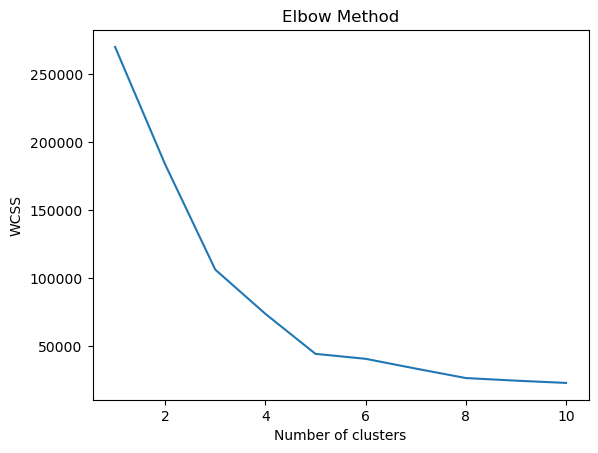

In [10]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

import matplotlib.pyplot as plt

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

## Applying K-Means Clustering

In [11]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X)

df['Cluster'] = y_kmeans
df.head()

C:\Users\ABHISHEK SHARMA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Visualizing Customer Segments

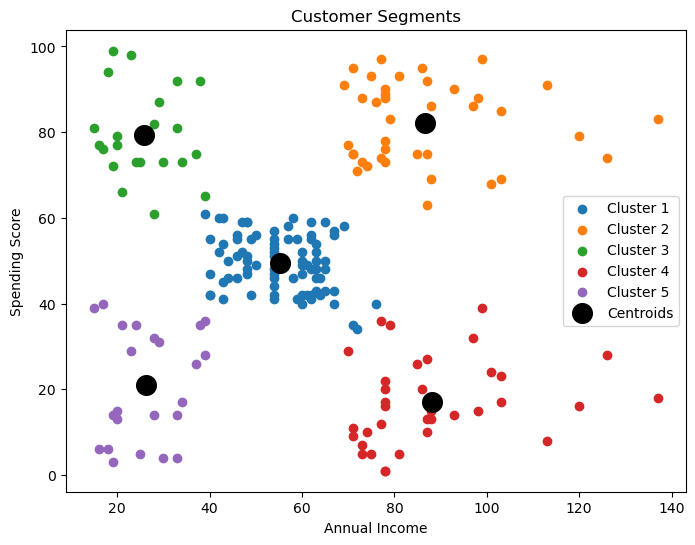

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(X[y_kmeans==0]['Annual Income (k$)'], 
            X[y_kmeans==0]['Spending Score (1-100)'], label='Cluster 1')

plt.scatter(X[y_kmeans==1]['Annual Income (k$)'], 
            X[y_kmeans==1]['Spending Score (1-100)'], label='Cluster 2')

plt.scatter(X[y_kmeans==2]['Annual Income (k$)'], 
            X[y_kmeans==2]['Spending Score (1-100)'], label='Cluster 3')

plt.scatter(X[y_kmeans==3]['Annual Income (k$)'], 
            X[y_kmeans==3]['Spending Score (1-100)'], label='Cluster 4')

plt.scatter(X[y_kmeans==4]['Annual Income (k$)'], 
            X[y_kmeans==4]['Spending Score (1-100)'], label='Cluster 5')

plt.scatter(kmeans.cluster_centers_[:,0], 
            kmeans.cluster_centers_[:,1], 
            s=200, c='black', label='Centroids')

plt.title("Customer Segments")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

## Insights

- High income & high spending customers are VIP customers  
- Low income but high spending customers are impulsive buyers  
- High income but low spending customers need engagement  
- Average customers give stable revenue  
- Low income & low spending customers are budget-focused  

## Business Recommendations

In [13]:
def recommend(cluster):
    if cluster == 0:
        return "Offer premium products & loyalty rewards"
    elif cluster == 1:
        return "Provide discounts & offers"
    elif cluster == 2:
        return "Target with personalized ads"
    elif cluster == 3:
        return "Upsell premium products"
    else:
        return "Focus on budget-friendly deals"

df['Recommendation'] = df['Cluster'].apply(recommend)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Recommendation
0,1,Male,19,15,39,4,Focus on budget-friendly deals
1,2,Male,21,15,81,2,Target with personalized ads
2,3,Female,20,16,6,4,Focus on budget-friendly deals
3,4,Female,23,16,77,2,Target with personalized ads
4,5,Female,31,17,40,4,Focus on budget-friendly deals


In [15]:
df.to_csv("customer_segments_output.csv", index=False)

In [2]:
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")

In [4]:
df.to_csv("customer_segments_output.csv", index=False)